Ce notebook explore différents modèles (Random Forest, XGBoost, etc.)
pour prédire le **cluster GMM** à partir des propriétés mécaniques.

Après qu'on a divisé les targets à des clusters , on va voir si on peut concevoir un modèle ML capable de prédire ces

In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [2]:
df=pd.read_csv("data_avec_clusters (1).csv")

In [3]:
df.drop(['Unnamed: 0.1',"Unnamed: 0"],axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639 entries, 0 to 1638
Data columns (total 48 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Carbon concentration (weight%)             1639 non-null   float64
 1   Silicon concentration (weight%)            1639 non-null   float64
 2   Manganese concentration (weight%)          1639 non-null   float64
 3   Sulphur concentration (weight%)            1639 non-null   float64
 4   Phosphorus concentration (weight%)         1639 non-null   float64
 5   Nickel concentration (weight%)             1639 non-null   float64
 6   Chromium concentration (weight%)           1639 non-null   float64
 7   Molybdenum concentration (weight%)         1639 non-null   float64
 8   Vanadium concentration (weight%)           1639 non-null   float64
 9   Copper concentration (weight%)             1639 non-null   float64
 10  Cobalt concentration (we

Aperçu rapide des données

In [ ]:
print("\n Statistiques descriptives :")
display(df.describe().T)

print("\n Répartition des clusters GMM :")
print(df["cluster_gmm"].value_counts(normalize=True).rename("proportion"))



 Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
Carbon concentration (weight%),1639.0,0.075418,0.024005,0.030000,0.060000,0.070000,0.080000,0.18
Silicon concentration (weight%),1639.0,0.328621,0.112815,0.040000,0.270000,0.320000,0.360000,1.14
Manganese concentration (weight%),1639.0,1.200134,0.382271,0.270000,0.930000,1.250000,1.440000,2.25
Sulphur concentration (weight%),1639.0,0.010122,0.011620,0.000000,0.010000,0.010000,0.010000,0.14
Phosphorus concentration (weight%),1639.0,0.013319,0.019660,0.000000,0.010000,0.010000,0.010000,0.25
Nickel concentration (weight%),1639.0,0.175973,0.552642,0.000000,0.000000,0.000000,0.030000,3.50
Chromium concentration (weight%),1639.0,1.004625,2.341385,0.000000,0.000000,0.000000,0.415000,10.20
Molybdenum concentration (weight%),1639.0,0.230915,0.409613,0.000000,0.000000,0.000000,0.270000,1.50
Vanadium concentration (weight%),1639.0,0.050940,0.334412,0.000000,0.000000,0.000000,0.010000,4.98
Copper concentration (weight%),1639.0,0.059829,0.208544,0.000000,0.000000,0.000000,0.000000,1.63



 Répartition des clusters GMM :
cluster_gmm
2.0    0.536303
0.0    0.417328
1.0    0.046370
Name: proportion, dtype: float64


Heatmap de corrélation

/tmp/ipython-input-2265371316.py:8: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


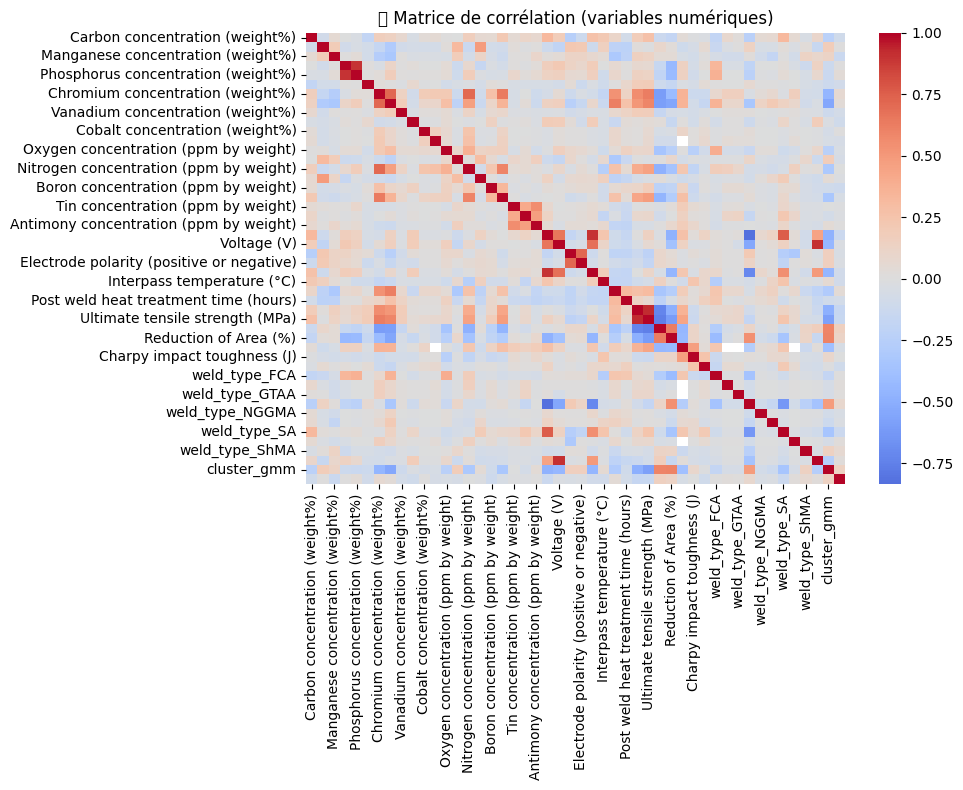

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("📌 Matrice de corrélation (variables numériques)")
plt.tight_layout()
plt.show()


In [4]:

y = df["cluster_gmm"]
features = ["cluster_proba","cluster_gmm","Yield strength (MPa)","Charpy impact toughness (J)","Reduction of Area (%)","Elongation (%)" ,"Ultimate tensile strength (MPa)","Charpy temperature (°C)"]

X = df.drop(columns=features)

print(X.shape, y.shape)


(1639, 40) (1639,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [6]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import numpy as np

On va essayer les différents modèles

In [7]:


models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=800,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=800,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="multi:softmax",     # prédire les classes
        num_class=len(np.unique(y)),
        random_state=42,
        n_jobs=-1,
    ),

    "LogisticRegression": LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=1000,
        n_jobs=-1
    ),

    "SVM_RBF": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5,
        weights="distance",
        metric="minkowski"
    ),

    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        n_estimators=300,
        learning_rate=0.1,
        random_state=42
    ),
}



In [8]:
results = {}

for name, model in models.items():
    print("="*40)
    print(f"Modèle : {name}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"Accuracy : {acc:.3f}")
    print("Classification report :")
    print(classification_report(y_test, y_pred))


Modèle : RandomForest
Accuracy : 0.954
Classification report :
              precision    recall  f1-score   support

         0.0       0.94      0.95      0.95       137
         1.0       0.93      0.93      0.93        15
         2.0       0.97      0.96      0.96       176

    accuracy                           0.95       328
   macro avg       0.95      0.95      0.95       328
weighted avg       0.95      0.95      0.95       328

Modèle : XGBoost
Accuracy : 0.954
Classification report :
              precision    recall  f1-score   support

         0.0       0.93      0.96      0.95       137
         1.0       0.93      0.93      0.93        15
         2.0       0.98      0.95      0.96       176

    accuracy                           0.95       328
   macro avg       0.95      0.95      0.95       328
weighted avg       0.95      0.95      0.95       328

Modèle : LogisticRegression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy : 0.890
Classification report :
              precision    recall  f1-score   support

         0.0       0.84      0.91      0.87       137
         1.0       1.00      0.13      0.24        15
         2.0       0.93      0.94      0.94       176

    accuracy                           0.89       328
   macro avg       0.92      0.66      0.68       328
weighted avg       0.90      0.89      0.88       328

Modèle : SVM_RBF
Accuracy : 0.811
Classification report :
              precision    recall  f1-score   support

         0.0       0.82      0.70      0.76       137
         1.0       0.00      0.00      0.00        15
         2.0       0.81      0.97      0.88       176

    accuracy                           0.81       328
   macro avg       0.54      0.56      0.54       328
weighted avg       0.78      0.81      0.79       328

Modèle : KNN
Accuracy : 0.905
Classification report :
              precision    recall  f1-score   support

         0.0       0.90      0

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy : 0.945
Classification report :
              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94       137
         1.0       0.93      0.93      0.93        15
         2.0       0.97      0.94      0.95       176

    accuracy                           0.95       328
   macro avg       0.94      0.94      0.94       328
weighted avg       0.95      0.95      0.95       328

Modèle : AdaBoost
Accuracy : 0.841
Classification report :
              precision    recall  f1-score   support

         0.0       0.78      0.87      0.82       137
         1.0       0.00      0.00      0.00        15
         2.0       0.90      0.89      0.89       176

    accuracy                           0.84       328
   macro avg       0.56      0.59      0.57       328
weighted avg       0.81      0.84      0.82       328



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


 Importance des features

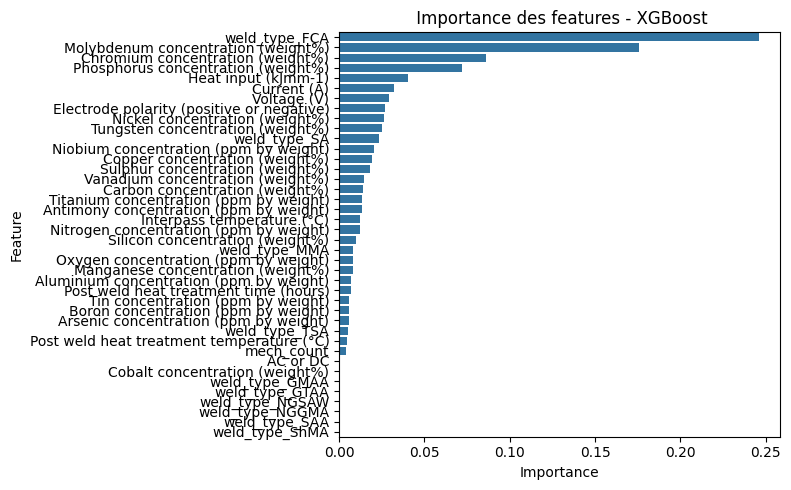

In [ ]:

xgb = models["XGBoost"]
importances_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
importances_xgb = importances_xgb.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=importances_xgb.values, y=importances_xgb.index)
plt.title(" Importance des features - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Cross-validation

In [9]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy", n_jobs=-1)
    print("="*50)
    print(f" Modèle : {name}")
    print(f"Scores CV : {scores}")
    print(f" Moyenne : {scores.mean():.3f} ± {scores.std():.3f}")


 Modèle : RandomForest
Scores CV : [0.92987805 0.93597561 0.94817073 0.96646341 0.96636086]
 Moyenne : 0.949 ± 0.015
 Modèle : XGBoost
Scores CV : [0.94207317 0.94207317 0.94207317 0.95426829 0.96024465]
 Moyenne : 0.948 ± 0.008
 Modèle : LogisticRegression
Scores CV : [0.84756098 0.89329268 0.84146341 0.88109756 0.87767584]
 Moyenne : 0.868 ± 0.020
 Modèle : SVM_RBF
Scores CV : [0.78658537 0.83841463 0.79878049 0.83536585 0.81651376]
 Moyenne : 0.815 ± 0.020
 Modèle : KNN
Scores CV : [0.89634146 0.92987805 0.91768293 0.91463415 0.91131498]
 Moyenne : 0.914 ± 0.011
 Modèle : GradientBoosting
Scores CV : [0.92073171 0.93292683 0.93292683 0.95121951 0.96941896]
 Moyenne : 0.941 ± 0.017
 Modèle : AdaBoost
Scores CV : [0.83841463 0.87804878 0.82012195 0.86280488 0.83486239]
 Moyenne : 0.847 ± 0.021


La plupart des modèles on fait de bon performance , donc le clustring qu'on a fait avant été une bonne idée.